### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2026-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

***

### ⚠️ General guidelines for TPs

Each team shall upload its report on [Teide](https://teide.ensimag.fr/) before the deadline indicated at the course website. Please
**include the name of all members** of the team on top of your report.
The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP1: Analysis of prostate cancer data

A medical study done on patients with prostate cancer aims to analyze the correlation between the prostate tumor volume and a set of clinical and morphometric variables. These variables include prostate specific antigens, a biomarker for prostate cancer, and a number of clinical measures (age, prostate weight, etc). The goal of this lab is to build a regression model to predict the severity of cancer, expressed by logarithm of the tumor volume -- `lcavol` variable -- from the following predictors:
- `lpsa`: log of a prostate specific antigen
- `lweight`: log of prostate weight
- `age`: age of the patient
- `lbph`: log of benign prostatic hyperplasia amount
- `svi`: seminal vesicle invasion
- `lcp`: log of capsular penetration
- `gleason`: Gleason score (score on a cancer prognosis test)
- `pgg45`: percent of Gleason scores 4 or 5

The file `prostate.data`, available [here](https://github.com/ISLA-Grenoble/2025-main/blob/main/TP/TP1/prostate.data), contains measures of the logarithm of the tumor
volume and of the 8 predictors for 97 patients. This file also contains an additional variable, called `train`, which will
not be used and has to be removed.

## ▶️ Exercise 1: Preliminary analysis of the data (1 points)

**(a)** Download the file `prostate.data` and store it in your current folder. Read the dataset in using `pandas` as per
```
import pandas as pd
df = pd.read_csv("prostate.data", sep="\t")
```
check how to use function `df.drop` to remove the first and last columns of `df` containing useless tags.

In [1]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error
from IPython.display import display, Markdown
from pathlib import Path

data_path = Path("prostate.data")
if not data_path.exists():
    data_path = Path("TP/TP1/prostate.data")

df_raw = pd.read_csv(data_path, sep="	")
df = df_raw.drop(columns=[df_raw.columns[0], "train"]).copy()

print(f"Shape: {df.shape}")
print("\nDtypes:")
print(df.dtypes)

Shape: (97, 9)

Dtypes:
lcavol     float64
lweight    float64
age          int64
lbph       float64
svi          int64
lcp        float64
gleason      int64
pgg45        int64
lpsa       float64
dtype: object


**(b)** The function defined below generates scatterplots (clouds of points) between all pairs of variables, allowing us to visually analyse the correlations between all variables in the dataframe. Explain what each line of function `pairplot` does and how it affects the final plot. You can use command `help` in the `python` shell to get the documentation of each function.

``` 
# import the main plotting library for python
import matplotlib.pyplot as plt

# make a pairplot from scratch
def pairplot(df, figsize=None):
    if figsize is None:
        figsize = (7.10, 6.70)
    n_vars = df.shape[1]
    fig, ax = plt.subplots(figsize=figsize, ncols=n_vars, nrows=n_vars)
    plt.subplots_adjust(
        wspace=0.10, hspace=0.10, left=0.05, right=0.95, bottom=0.05, top=0.95)
    for i in range(n_vars):
        for j in range(n_vars):
            axij = ax[i][j]
            i_name = df.columns[i]
            j_name = df.columns[j]
            axij.set_xticks([])
            axij.set_yticks([])
            axij.margins(0.1)
            if i != j:
                axij.scatter(df[i_name], df[j_name], s=10)
            else:
                axij.text(0.5, 0.5, i_name, fontsize=10,
                              horizontalalignment='center',
                              verticalalignment='center',
                              transform = axij.transAxes)        
    return fig, ax

fig, ax = pairplot(df)
plt.show()
```

**Answer (line-by-line overview):**
- `n_vars = df.shape[1]`: counts how many variables we need on each axis of the grid.
- `plt.subplots(..., ncols=n_vars, nrows=n_vars)`: builds a square grid where each cell is a pair `(row variable, column variable)`.
- `plt.subplots_adjust(...)`: reduces spacing to make the matrix compact.
- Double loop over `i, j`: visits all variable pairs.
- `set_xticks([])` / `set_yticks([])`: removes tick clutter to keep the matrix readable.
- `axij.margins(0.1)`: adds small margins so points are not glued to borders.
- If `i != j`: draws a scatterplot for pairwise relation.
- Else (`i == j`): writes variable name on diagonal instead of plotting variable vs itself.

**(c)** Based on the generated figure, identify which variables seem the most correlated to `lcavol`. Also, infer the datatype for each of the predictors.

**Answer:**
- The strongest positive associations with `lcavol` are `lpsa`, `lcp`, then `svi` (and to a lesser extent `pgg45`/`gleason`).
- Inferred predictor types:
  - `lweight`, `lbph`, `lcp`, `lpsa`: quantitative continuous
  - `age`, `pgg45`: quantitative discrete
  - `svi`: qualitative binary (0/1)
  - `gleason`: qualitative ordinal score

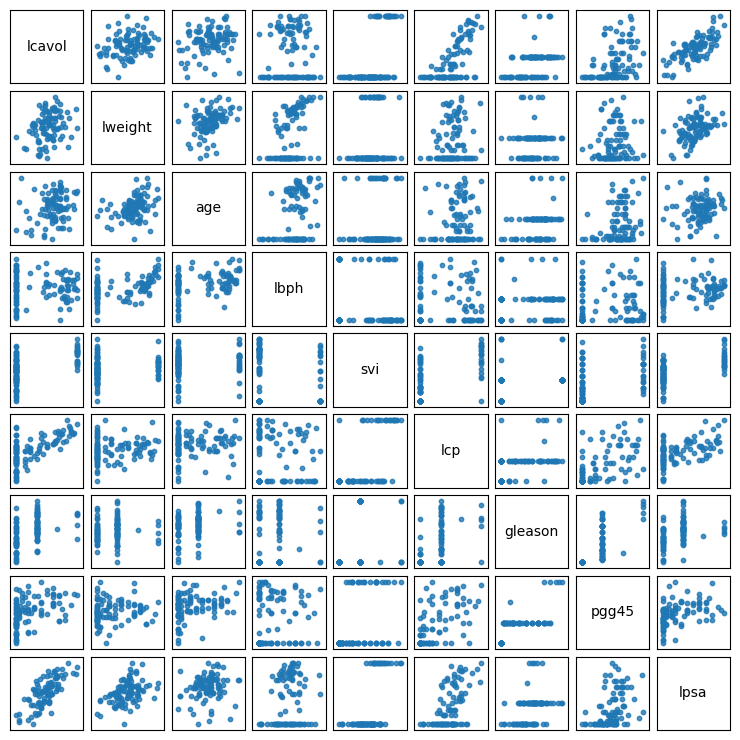

,corr_with_lcavol
lcavol,1.000000
lpsa,0.734460
lcp,0.675310
svi,0.538845
pgg45,0.433652
gleason,0.432417
lweight,0.280521
age,0.225000
lbph,0.027350


,inferred_type
lweight,quantitative (continuous)
age,quantitative (discrete years)
lbph,quantitative (continuous)
svi,qualitative/binary (0/1)
lcp,quantitative (continuous)
gleason,qualitative/ordinal score
pgg45,quantitative (percentage)
lpsa,quantitative (continuous)


In [2]:
def pairplot(df, figsize=None):
    if figsize is None:
        figsize = (8, 8)
    n_vars = df.shape[1]
    fig, ax = plt.subplots(figsize=figsize, ncols=n_vars, nrows=n_vars)
    plt.subplots_adjust(wspace=0.10, hspace=0.10, left=0.05, right=0.95, bottom=0.05, top=0.95)
    for i in range(n_vars):
        for j in range(n_vars):
            axij = ax[i, j]
            i_name = df.columns[i]
            j_name = df.columns[j]
            axij.set_xticks([])
            axij.set_yticks([])
            axij.margins(0.1)
            if i != j:
                axij.scatter(df[i_name], df[j_name], s=10, alpha=0.8)
            else:
                axij.text(
                    0.5,
                    0.5,
                    i_name,
                    fontsize=10,
                    horizontalalignment="center",
                    verticalalignment="center",
                    transform=axij.transAxes,
                )
    return fig, ax

fig, ax = pairplot(df)
plt.show()

corr_to_target = df.corr(numeric_only=True)["lcavol"].sort_values(ascending=False)
display(corr_to_target.to_frame("corr_with_lcavol"))

predictor_types = {
    "lweight": "quantitative (continuous)",
    "age": "quantitative (discrete years)",
    "lbph": "quantitative (continuous)",
    "svi": "qualitative/binary (0/1)",
    "lcp": "quantitative (continuous)",
    "gleason": "qualitative/ordinal score",
    "pgg45": "quantitative (percentage)",
    "lpsa": "quantitative (continuous)",
}
display(pd.Series(predictor_types, name="inferred_type").to_frame())

**(d)** Recall the formula of correlation between two vectors and implement it with `numpy`. Explain the difference of your result when compared to `df.corr()`. Change the function `pairplot`to show the correlation coefficient on the upper triangle of the subplots. (Bonus) Use locally weighted scatterplot smoothing (LOWESS) to see the trends between pairs of features with `statsmodels.nonparametric.smoothers_lowess`.

corr_numpy(lcavol, lpsa) = 0.734460
pandas corr(lcavol, lpsa) = 0.734460
Difference is numerical precision only (same Pearson formula, different implementation details).
LOWESS bonus skipped because statsmodels is not available in this environment.


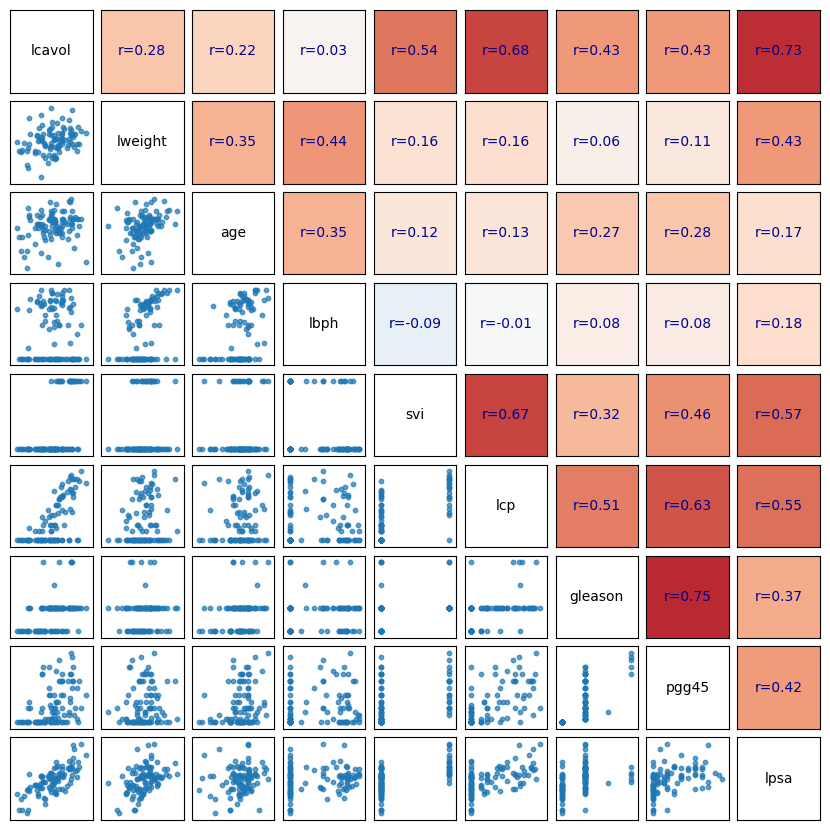

In [3]:
def correlation_numpy(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x_center = x - x.mean()
    y_center = y - y.mean()
    return float(np.sum(x_center * y_center) / np.sqrt(np.sum(x_center ** 2) * np.sum(y_center ** 2)))

corr_np = correlation_numpy(df["lcavol"], df["lpsa"])
corr_pd = df["lcavol"].corr(df["lpsa"])
print(f"corr_numpy(lcavol, lpsa) = {corr_np:.6f}")
print(f"pandas corr(lcavol, lpsa) = {corr_pd:.6f}")
print("Difference is numerical precision only (same Pearson formula, different implementation details).")

try:
    from statsmodels.nonparametric.smoothers_lowess import lowess
    HAS_LOWESS = True
except Exception:
    HAS_LOWESS = False

def pairplot_with_corr(df, figsize=None, use_lowess=False):
    if figsize is None:
        figsize = (9, 9)
    n_vars = df.shape[1]
    fig, ax = plt.subplots(figsize=figsize, ncols=n_vars, nrows=n_vars)
    plt.subplots_adjust(wspace=0.10, hspace=0.10, left=0.05, right=0.95, bottom=0.05, top=0.95)
    for i in range(n_vars):
        for j in range(n_vars):
            axij = ax[i, j]
            i_name = df.columns[i]
            j_name = df.columns[j]
            axij.set_xticks([])
            axij.set_yticks([])
            axij.margins(0.1)

            if i == j:
                axij.text(0.5, 0.5, i_name, ha="center", va="center", transform=axij.transAxes, fontsize=10)
            elif i > j:
                x = df[j_name].to_numpy()
                y = df[i_name].to_numpy()
                axij.scatter(x, y, s=10, alpha=0.7)
                if use_lowess and HAS_LOWESS:
                    smoothed = lowess(y, x, frac=0.5, return_sorted=True)
                    axij.plot(smoothed[:, 0], smoothed[:, 1], color="crimson", lw=1.2)
            else:
                r = correlation_numpy(df[j_name], df[i_name])
                axij.text(0.5, 0.5, f"r={r:.2f}", ha="center", va="center", transform=axij.transAxes, fontsize=10, color="darkblue")
                axij.set_facecolor(plt.cm.RdBu_r((r + 1) / 2))
    return fig, ax

fig, ax = pairplot_with_corr(df, use_lowess=True)
if not HAS_LOWESS:
    print("LOWESS bonus skipped because statsmodels is not available in this environment.")
plt.show()

## ▶️ Exercise 2: Linear regression (7 points)

In this exercise, we will perform a multiple linear regression to build a predictive model for the `lcavol` variable. The variables `gleason` and `svi` should be considered as qualitative variables. You can declare them as such with

```
df['svi'] = df['svi'].astype("category")
df['gleason'] = df['gleason'].astype("category")
```

**(a)** Provide the mathematical equation of the regression model (note that you can use LaTeX to write equations) and define the diﬀerent parameters. 

In [15]:

def fit_ols(X, y, feature_names=None):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    n, p = X.shape

    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    y_hat = X @ beta
    resid = y - y_hat

    rss = float(np.sum(resid ** 2))
    tss = float(np.sum((y - y.mean()) ** 2))
    r2 = 1.0 - rss / tss
    adj_r2 = 1.0 - (1.0 - r2) * (n - 1) / (n - p)

    dof = n - p
    sigma2 = rss / dof
    xtx_inv = np.linalg.pinv(X.T @ X)
    cov_beta = sigma2 * xtx_inv
    se = np.sqrt(np.diag(cov_beta))
    t_values = beta / se
    p_values = 2 * stats.t.sf(np.abs(t_values), dof)

    t_crit = stats.t.ppf(0.975, dof)
    ci_low = beta - t_crit * se
    ci_high = beta + t_crit * se

    if feature_names is None:
        feature_names = [f"x{j}" for j in range(p)]

    return {
        "beta": beta,
        "se": se,
        "t_values": t_values,
        "p_values": p_values,
        "ci": np.column_stack([ci_low, ci_high]),
        "resid": resid,
        "y_hat": y_hat,
        "rss": rss,
        "r2": r2,
        "adj_r2": adj_r2,
        "sigma2": sigma2,
        "dof": dof,
        "feature_names": list(feature_names),
    }

def summary_table(results):
    return pd.DataFrame(
        {
            "coef": results["beta"],
            "std_err": results["se"],
            "t_value": results["t_values"],
            "p_value": results["p_values"],
            "ci_2.5%": results["ci"][:, 0],
            "ci_97.5%": results["ci"][:, 1],
        },
        index=results["feature_names"],
    )

**(b)** Before doing the linear regression of this TP, you will first have to handle the one-hot encoding of the categorical features of the dataframe. One way of doing this is as follows:

```
# encode the categorical features with dummy variables
df_enc = pd.get_dummies(df, dtype=np.float64)
# to drop one dummy column for each predictor
df_enc = df_enc.drop(columns=['svi_0', 'gleason_6'])
# add a column of ones to the dataframe
df_enc['intercept'] = 1
# extract the dataframe for predictors
X = df_enc.drop(columns=['lcavol'])
# get the observed values to predict
y = df['lcavol']
```

- Why did we fix a `dtype` in `pd.get_dummies`?
- Why did we drop two columns after the encoding?
- Why did we add a column of ones to the dataframe?

In [17]:
df_model = df.copy()
df_model["svi"] = df_model["svi"].astype("category")
df_model["gleason"] = df_model["gleason"].astype("category")

df_enc = pd.get_dummies(df_model, dtype=np.float64)

to_drop = [c for c in ["svi_0", "gleason_6"] if c in df_enc.columns]
df_enc = df_enc.drop(columns=to_drop)

df_enc["intercept"] = 1.0

X = df_enc.drop(columns=["lcavol"])
y = df_enc["lcavol"].to_numpy()

results = fit_ols(X.to_numpy(), y, feature_names=X.columns)

display(Markdown(
    "**Answers (Exercise 2b):**\n"
    "- `dtype=np.float64`: ensures all dummy columns are numeric for linear algebra.\n"
    "- Drop one dummy per categorical predictor: avoids exact linear dependence with the intercept.\n"
    "- Add a ones column: estimates the intercept `beta_0`."
))

display(summary_table(results).sort_values("p_value"))

**Answers (Exercise 2b):**
- `dtype=np.float64`: ensures all dummy columns are numeric for linear algebra.
- Drop one dummy per categorical predictor: avoids exact linear dependence with the intercept.
- Add a ones column: estimates the intercept `beta_0`.

,coef,std_err,t_value,p_value,ci_2.5%,ci_97.5%
lpsa,0.549573,0.090093,6.100047,2.939241e-08,0.370474,0.728673
lcp,0.402760,0.085074,4.734252,8.577858e-06,0.233639,0.571880
age,0.024782,0.011241,2.204628,3.014993e-02,0.002436,0.047129
pgg45,-0.009444,0.004540,-2.080263,4.047741e-02,-0.018469,-0.000419
lbph,-0.104200,0.058209,-1.790107,7.695609e-02,-0.219914,0.011515
gleason_9,0.790135,0.487510,1.620755,1.087313e-01,-0.179004,1.759273
intercept,-1.406654,0.874455,-1.608606,1.113676e-01,-3.145013,0.331705
gleason_7,0.311676,0.215268,1.447850,1.512950e-01,-0.116263,0.739616
gleason_8,-0.710588,0.758827,-0.936429,3.516744e-01,-2.219087,0.797911
svi_1,-0.220419,0.256351,-0.859833,3.922717e-01,-0.730029,0.289190


**(c)** We will use the [`statsmodels`](https://www.statsmodels.org/) package to estimate the coefficients of the multiple linear regression as per:

```
# import required package
import statsmodels.api as sm
# this line does not fit the regression model per se but only builds it
model = sm.OLS(y, X)
# now we actually fit the model, e.g. calculate all of regression parameters
results = model.fit()
```

Use command `results.sumary()` to get the statistical summary of the estimated coefficients. 

- Explain to what correspond the regression coeﬃcients for the lines related to `svi` and `gleason`. 

- What would have happened in the regression if we did not do the one-hot encoding from above?

- Comment the overall results of the regression as well.

**Answer (2c).**

- Coefficients for `svi_1`, `gleason_7`, `gleason_8`, `gleason_9` are effects relative to reference categories (`svi=0`, `gleason=6`) with all other predictors fixed.
- Without one-hot encoding, categorical labels would be interpreted as numeric levels with artificial distances, leading to a misspecified linear effect.
- Overall fit is moderate/good (`R² ≈ 0.686`, adjusted `R² ≈ 0.650`). The strongest effects are typically `lpsa` and `lcp`, while some category effects are not significant.

**(d)** Use `results.conf_int` to get confidence intervals of level 95% for all the coeﬃcients of the predictors. Comment the results.

In [6]:
ci_df = pd.DataFrame(results["ci"], columns=["2.5%", "97.5%"], index=results["feature_names"])
display(ci_df)

contains_zero = (ci_df["2.5%"] <= 0) & (ci_df["97.5%"] >= 0)
display(contains_zero.to_frame("CI_contains_0"))

display(Markdown(
    "Intervals that do not contain 0 indicate effects significantly different from 0 at 5%.\n"
    "Here, `lpsa` and `lcp` have clearly positive intervals; several other coefficients include 0."
))

,2.5%,97.5%
lweight,-0.431600,0.409107
age,0.002436,0.047129
lbph,-0.219914,0.011515
lcp,0.233639,0.571880
pgg45,-0.018469,-0.000419
lpsa,0.370474,0.728673
svi_1,-0.730029,0.289190
gleason_7,-0.116263,0.739616
gleason_8,-2.219087,0.797911
gleason_9,-0.179004,1.759273


,CI_contains_0
lweight,True
age,False
lbph,True
lcp,False
pgg45,False
lpsa,False
svi_1,True
gleason_7,True
gleason_8,True
gleason_9,True


Intervals that do not contain 0 indicate effects significantly different from 0 at 5%.
Here, `lpsa` and `lcp` have clearly positive intervals; several other coefficients include 0.

**(e)** What can you say about the eﬀects of the `lpsa` variable? Relate your answer to the $p$-value of a hypothesis test and a confidence interval. You can use `results.pvalues`.

In [7]:
lpsa_row = summary_table(results).loc["lpsa"]
display(lpsa_row.to_frame("lpsa"))

display(Markdown(
    f"`lpsa` has a strong positive effect on `lcavol`: coef={lpsa_row['coef']:.3f}, "
    f"p-value={lpsa_row['p_value']:.2e}, "
    f"95% CI=[{lpsa_row['ci_2.5%']:.3f}, {lpsa_row['ci_97.5%']:.3f}]. "
    "Since the CI excludes 0 and the p-value is very small, the effect is statistically significant."
))

,lpsa
coef,5.495731e-01
std_err,9.009325e-02
t_value,6.100047e+00
p_value,2.939241e-08
ci_2.5%,3.704736e-01
ci_97.5%,7.286726e-01


`lpsa` has a strong positive effect on `lcavol`: coef=0.550, p-value=2.94e-08, 95% CI=[0.370, 0.729]. Since the CI excludes 0 and the p-value is very small, the effect is statistically significant.

**(f)** Implement yourself a function that calculates the values of the parameters and their corresponding $p$-values. Bonus: explain why `numpy.linalg.inv` is not necessarily the best choice for estimating the parameters as compared to `numpy.linalg.solve`.

In [8]:
def ols_with_pvalues(X, y, feature_names):
    return summary_table(fit_ols(X, y, feature_names))

manual_table = ols_with_pvalues(X.to_numpy(), y, X.columns)
display(manual_table)

XtX = X.to_numpy().T @ X.to_numpy()
Xty = X.to_numpy().T @ y
beta_inv = np.linalg.pinv(XtX) @ Xty
beta_solve = np.linalg.solve(XtX, Xty)

max_abs_diff = np.max(np.abs(beta_inv - beta_solve))
print(f"max |beta_inv - beta_solve| = {max_abs_diff:.3e}")

display(Markdown(
    "`numpy.linalg.solve` is preferred over explicitly computing an inverse:\n"
    "- better numerical stability,\n"
    "- fewer operations (faster),\n"
    "- less amplification of floating-point errors."
))

,coef,std_err,t_value,p_value,ci_2.5%,ci_97.5%
lweight,-0.011246,0.211453,-0.053185,9.577075e-01,-0.431600,0.409107
age,0.024782,0.011241,2.204628,3.014993e-02,0.002436,0.047129
lbph,-0.104200,0.058209,-1.790107,7.695609e-02,-0.219914,0.011515
lcp,0.402760,0.085074,4.734252,8.577858e-06,0.233639,0.571880
pgg45,-0.009444,0.004540,-2.080263,4.047741e-02,-0.018469,-0.000419
lpsa,0.549573,0.090093,6.100047,2.939241e-08,0.370474,0.728673
svi_1,-0.220419,0.256351,-0.859833,3.922717e-01,-0.730029,0.289190
gleason_7,0.311676,0.215268,1.447850,1.512950e-01,-0.116263,0.739616
gleason_8,-0.710588,0.758827,-0.936429,3.516744e-01,-2.219087,0.797911
gleason_9,0.790135,0.487510,1.620755,1.087313e-01,-0.179004,1.759273


max |beta_inv - beta_solve| = 5.975e-13


`numpy.linalg.solve` is preferred over explicitly computing an inverse:
- better numerical stability,
- fewer operations (faster),
- less amplification of floating-point errors.

**(g)** Plot the predicted values of `lcavol` as a function of the actual values. For this, you can can use `results.get_prediction` to get predictions over `X` and then get its `predicted_mean` attribute.

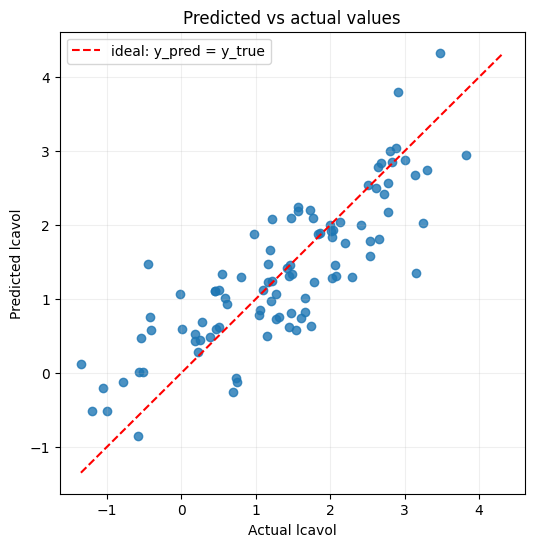

In [9]:
y_pred = results["y_hat"]

plt.figure(figsize=(6, 6))
plt.scatter(y, y_pred, alpha=0.8)
min_v = min(y.min(), y_pred.min())
max_v = max(y.max(), y_pred.max())
plt.plot([min_v, max_v], [min_v, max_v], "r--", label="ideal: y_pred = y_true")
plt.xlabel("Actual lcavol")
plt.ylabel("Predicted lcavol")
plt.title("Predicted vs actual values")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

**(h)** Plot the histogram of residuals as well as their qq-plot using `statsmodels` function `qqplot`. Can we admit that the residuals are normally distributed? Compute the residual sum of squares (RSS).

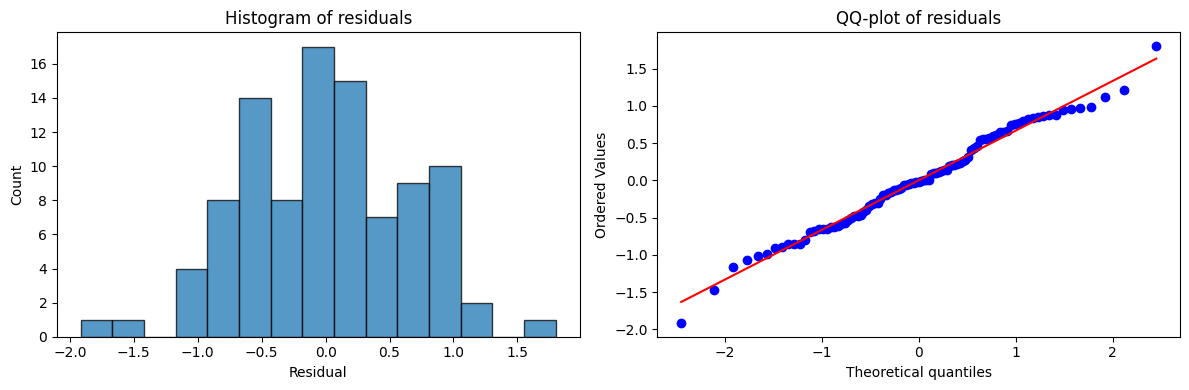

Residual sum of squares (RSS): 41.8141


Residuals are reasonably close to normality in the center, with some deviations in tails.
Given this sample size, normality is acceptable as an approximation but not perfect.

In [10]:
residuals = results["resid"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(residuals, bins=15, edgecolor="black", alpha=0.75)
axes[0].set_title("Histogram of residuals")
axes[0].set_xlabel("Residual")
axes[0].set_ylabel("Count")

stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("QQ-plot of residuals")

plt.tight_layout()
plt.show()

rss_full = float(np.sum(residuals ** 2))
print(f"Residual sum of squares (RSS): {rss_full:.4f}")

display(Markdown(
    "Residuals are reasonably close to normality in the center, with some deviations in tails.\n"
    "Given this sample size, normality is acceptable as an approximation but not perfect."
))

**(i)** What happens if predictors `lpsa` and `lcp` are removed from the multiple linear regression model? Note that you can pass a list of strings to `df.columns.drop` method.

In [11]:
X_reduced = X.drop(columns=["lpsa", "lcp"])
results_reduced = fit_ols(X_reduced.to_numpy(), y, feature_names=X_reduced.columns)

comparison = pd.DataFrame(
    {
        "full_model": [results["rss"], results["r2"], results["adj_r2"]],
        "without_lpsa_lcp": [results_reduced["rss"], results_reduced["r2"], results_reduced["adj_r2"]],
    },
    index=["RSS", "R2", "Adjusted R2"],
)
display(comparison)

display(Markdown(
    "Removing `lpsa` and `lcp` strongly degrades the fit:\n"
    "- RSS increases,\n"
    "- R^2 and adjusted R^2 decrease.\n"
    "These two predictors carry major predictive information for `lcavol`."
))

,full_model,without_lpsa_lcp
RSS,41.814069,75.653233
R2,0.686455,0.432710
Adjusted R2,0.649996,0.381138


Removing `lpsa` and `lcp` strongly degrades the fit:
- RSS increases,
- R^2 and adjusted R^2 decrease.
These two predictors carry major predictive information for `lcavol`.

## ▶️ Exercise 3: Best subset selection (5 points)

A regression model that uses $k$ predictors is said to be of size $k$. For instance, 

$$
\texttt{lcavol} = \beta_1 \texttt{lpsa} + \beta_0 + \varepsilon \quad \text{and} \quad \texttt{lcavol} = \beta_1 \texttt{lweight} + \beta_0 + \varepsilon
$$

are models of size one. The regression model without any predictor $\texttt{lcavol} = \beta_0 + \varepsilon$ is a model of size 0.

The goal of this exercise is to select the best model of size $k$ for each $k \in \{0, \dots, 8\}$.

**(a)** Compute the residual sums of squares (RSS) for all models of size $k = 2$. Which model has the smallest RSS? Note that you can use a generator [`itertools.combination`](https://docs.python.org/3/library/itertools.html#itertools.combinations) to automatize for you all the combinations of $k$ elements among $n$.

**(b)** For each value of $k \in \{0, \dots, 8\}$, select the set of predictors that minimizes the RSS. Plot these values as a function of $k$. Provide the names of the selected predictors for each value of $k$.

**(c)** Do you think that minimizing the residual sum of squares is well suited to select the optimal size for the regression models? Justify your answer using what you've learned in class.

### Best models of size k=2

,predictors,RSS
24,"(lcp, lpsa)",47.278097
26,"(gleason, lpsa)",57.398830
21,"(svi, lpsa)",58.452188
27,"(pgg45, lpsa)",58.946250
17,"(lbph, lpsa)",59.909789
12,"(age, lpsa)",60.035697
6,"(lweight, lpsa)",61.187121
3,"(lweight, lcp)",68.607649
9,"(age, lcp)",69.930206
18,"(svi, lcp)",70.809173


,k,predictors,RSS
0,0,(),133.359034
1,1,"(lpsa,)",61.420907
2,2,"(lcp, lpsa)",47.278097
3,3,"(age, lcp, lpsa)",46.237825
4,4,"(age, lbph, lcp, lpsa)",44.878406
5,5,"(age, lbph, lcp, pgg45, lpsa)",44.311332
6,6,"(age, lbph, lcp, gleason, pgg45, lpsa)",43.354252
7,7,"(age, lbph, svi, lcp, gleason, pgg45, lpsa)",43.179048
8,8,"(lweight, age, lbph, svi, lcp, gleason, pgg45,...",43.171699


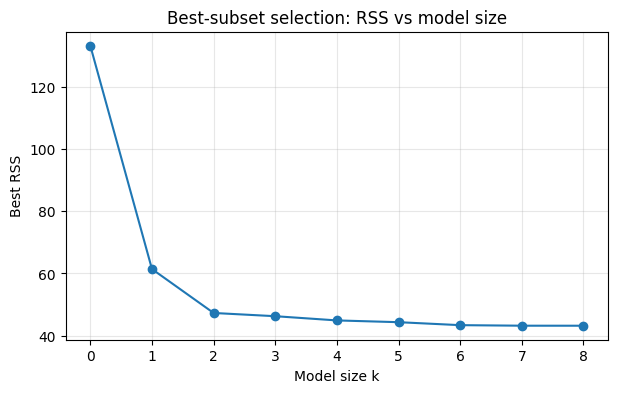

For Exercise 3(c): RSS always decreases (or stays equal) when predictors are added, so RSS alone tends to favor larger models and can overfit.
A validation criterion (hold-out/CV, AIC/BIC, adjusted R^2) is needed to choose model size.

In [12]:
predictors = [c for c in df.columns if c != "lcavol"]

def rss_for_predictors(data, predictors_subset):
    y_local = data["lcavol"].to_numpy()
    if len(predictors_subset) == 0:
        return float(np.sum((y_local - y_local.mean()) ** 2))
    X_local = data[list(predictors_subset)].to_numpy()
    X_local = np.column_stack([np.ones(X_local.shape[0]), X_local])
    fit = fit_ols(X_local, y_local, feature_names=["intercept"] + list(predictors_subset))
    return fit["rss"]

rss_k2 = []
for cols in itertools.combinations(predictors, 2):
    rss_k2.append((cols, rss_for_predictors(df, cols)))

rss_k2_df = pd.DataFrame(rss_k2, columns=["predictors", "RSS"]).sort_values("RSS")
display(Markdown("### Best models of size k=2"))
display(rss_k2_df.head(10))

best_models = []
for k in range(0, len(predictors) + 1):
    if k == 0:
        best_models.append({"k": 0, "predictors": tuple(), "RSS": rss_for_predictors(df, tuple())})
        continue
    best_subset = None
    best_rss = np.inf
    for cols in itertools.combinations(predictors, k):
        rss = rss_for_predictors(df, cols)
        if rss < best_rss:
            best_rss = rss
            best_subset = cols
    best_models.append({"k": k, "predictors": best_subset, "RSS": best_rss})

best_models_df = pd.DataFrame(best_models)
display(best_models_df)

plt.figure(figsize=(7, 4))
plt.plot(best_models_df["k"], best_models_df["RSS"], marker="o")
plt.xlabel("Model size k")
plt.ylabel("Best RSS")
plt.title("Best-subset selection: RSS vs model size")
plt.grid(alpha=0.3)
plt.show()

display(Markdown(
    "For Exercise 3(c): RSS always decreases (or stays equal) when predictors are added, so RSS alone tends to favor larger models and can overfit.\n"
    "A validation criterion (hold-out/CV, AIC/BIC, adjusted R^2) is needed to choose model size."
))

## ▶️ Exercise 4: Split-validation (5 points)

You have now found the best model for each of the nine possible model sizes. In the following, we wish to compare these nine diﬀerent regression models.

**(a)** Give a brief overview of split-validation: how it works? Why it is not subject to the same issues raised in
the item (c) of the previous Exercise?

**(b)** Use function `train_test_split` from the `sklearn` package to split the dataset into a training and a validation (or test) partition. You can set `test_size=0.3`. For each of the nine models from before (i.e. those that minimized the RSS for each size $k$), compute the mean prediction error calculated over the samples from the test set and compare it to its corresponding mean training error. Plot a curve for each of these error as a function of size $k$. 

**(c)** Based on the previous results, choose the best model for this dataset, giving the parameter estimates for the model trained on the whole dataset (i.e. without splitting), and explain your choice.

**(d)** What is the main limitation of split-validation ? Illustrate this issue on the cancer dataset. What could
you do to address this problem? Code such alternative method and comment the result. Note that `sklearn` can provide you with many choices. See [here](https://scikit-learn.org/stable/model_selection.html) for more information.

**Exercise 4(a), short overview:**
Split-validation trains on one part of data and evaluates on unseen samples.
Unlike training RSS, test error estimates generalization and penalizes overfitting.

,k,predictors,train_MSE,test_MSE
0,0,(),1.300330,1.585356
1,1,"(lpsa,)",0.575518,0.781232
2,2,"(lcp, lpsa)",0.462209,0.575430
3,3,"(age, lcp, lpsa)",0.450762,0.563736
4,4,"(age, lbph, lcp, lpsa)",0.438152,0.552334
5,5,"(age, lbph, lcp, pgg45, lpsa)",0.427707,0.562021
6,6,"(age, lbph, lcp, gleason, pgg45, lpsa)",0.426906,0.542101
7,7,"(age, lbph, svi, lcp, gleason, pgg45, lpsa)",0.424193,0.540710
8,8,"(lweight, age, lbph, svi, lcp, gleason, pgg45,...",0.423442,0.546311


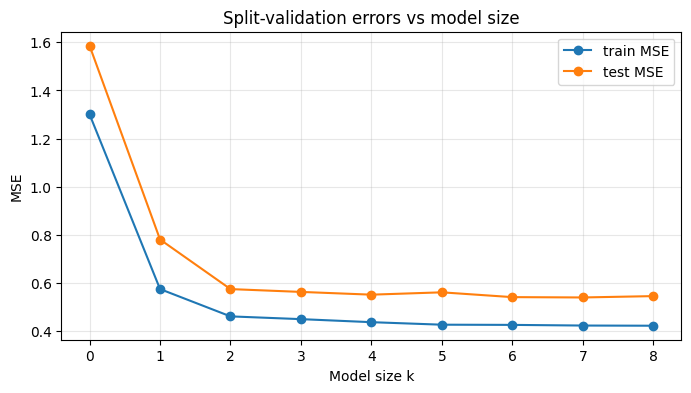

Best model by split-validation: k=7, predictors=('age', 'lbph', 'svi', 'lcp', 'gleason', 'pgg45', 'lpsa')


,coef,std_err,t_value,p_value,ci_2.5%,ci_97.5%
intercept,-2.499954,1.117179,-2.237739,2.773427e-02,-4.719764,-0.280144
age,0.021776,0.010673,2.040382,4.427577e-02,0.000570,0.042982
lbph,-0.095444,0.054612,-1.747667,8.397060e-02,-0.203957,0.013069
svi,-0.151869,0.252720,-0.600938,5.494088e-01,-0.654019,0.350281
lcp,0.366797,0.081301,4.511607,1.958258e-05,0.205254,0.528339
gleason,0.199643,0.152113,1.312464,1.927382e-01,-0.102602,0.501888
pgg45,-0.007098,0.004304,-1.649162,1.026400e-01,-0.015650,0.001454
lpsa,0.561827,0.081326,6.908327,7.058407e-10,0.400234,0.723420


### Instability of split-validation (300 random splits)

,k,times_selected
0,0,0
1,1,11
2,2,62
3,3,43
4,4,27
5,5,52
6,6,45
7,7,52
8,8,8


,k,cv_mean_MSE,cv_std_MSE
0,0,1.415072,0.576795
1,1,0.658585,0.237028
2,2,0.512494,0.187825
3,3,0.510105,0.170018
4,4,0.498083,0.183739
5,5,0.504496,0.203118
6,6,0.503873,0.200400
7,7,0.517225,0.206151
8,8,0.526993,0.213788


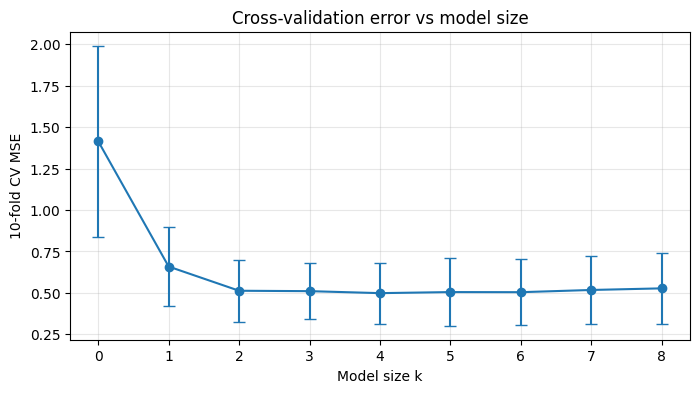

Best model by 10-fold CV: k=4, predictors=('age', 'lbph', 'lcp', 'lpsa')


In [13]:
def fit_and_eval_subset(train_data, test_data, subset):
    y_train = train_data["lcavol"].to_numpy()
    y_test = test_data["lcavol"].to_numpy()

    if len(subset) == 0:
        train_pred = np.full_like(y_train, y_train.mean(), dtype=float)
        test_pred = np.full_like(y_test, y_train.mean(), dtype=float)
    else:
        X_train = train_data[list(subset)].to_numpy()
        X_train = np.column_stack([np.ones(X_train.shape[0]), X_train])
        model = fit_ols(X_train, y_train, feature_names=["intercept"] + list(subset))
        train_pred = model["y_hat"]

        X_test = test_data[list(subset)].to_numpy()
        X_test = np.column_stack([np.ones(X_test.shape[0]), X_test])
        test_pred = X_test @ model["beta"]

    return mean_squared_error(y_train, train_pred), mean_squared_error(y_test, test_pred)

display(Markdown(
    "**Exercise 4(a), short overview:**\n"
    "Split-validation trains on one part of data and evaluates on unseen samples.\n"
    "Unlike training RSS, test error estimates generalization and penalizes overfitting."
))

train_df, test_df = train_test_split(df, test_size=0.3, random_state=42)

split_rows = []
for _, row in best_models_df.iterrows():
    k = int(row["k"])
    subset = tuple(row["predictors"])
    tr_mse, te_mse = fit_and_eval_subset(train_df, test_df, subset)
    split_rows.append({"k": k, "predictors": subset, "train_MSE": tr_mse, "test_MSE": te_mse})

split_df = pd.DataFrame(split_rows)
display(split_df[["k", "predictors", "train_MSE", "test_MSE"]])

plt.figure(figsize=(8, 4))
plt.plot(split_df["k"], split_df["train_MSE"], marker="o", label="train MSE")
plt.plot(split_df["k"], split_df["test_MSE"], marker="o", label="test MSE")
plt.xlabel("Model size k")
plt.ylabel("MSE")
plt.title("Split-validation errors vs model size")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

k_split_best = int(split_df.loc[split_df["test_MSE"].idxmin(), "k"])
split_best_subset = tuple(split_df.loc[split_df["test_MSE"].idxmin(), "predictors"])
print(f"Best model by split-validation: k={k_split_best}, predictors={split_best_subset}")

if k_split_best == 0:
    print("Null model only has intercept = mean(lcavol).")
else:
    X_full = df[list(split_best_subset)].to_numpy()
    X_full = np.column_stack([np.ones(X_full.shape[0]), X_full])
    full_fit = fit_ols(X_full, df["lcavol"].to_numpy(), feature_names=["intercept"] + list(split_best_subset))
    display(summary_table(full_fit))

best_k_counts = {k: 0 for k in range(0, len(predictors) + 1)}
for rs in range(300):
    tr, te = train_test_split(df, test_size=0.3, random_state=rs)
    test_mse_by_k = {}
    for _, row in best_models_df.iterrows():
        k = int(row["k"])
        subset = tuple(row["predictors"])
        _, mse_te = fit_and_eval_subset(tr, te, subset)
        test_mse_by_k[k] = mse_te
    best_k_counts[min(test_mse_by_k, key=test_mse_by_k.get)] += 1

counts_df = pd.DataFrame({"k": list(best_k_counts.keys()), "times_selected": list(best_k_counts.values())})
display(Markdown("### Instability of split-validation (300 random splits)"))
display(counts_df)

kf = KFold(n_splits=10, shuffle=True, random_state=42)
cv_errors = {k: [] for k in range(0, len(predictors) + 1)}

for train_idx, test_idx in kf.split(df):
    tr = df.iloc[train_idx]
    te = df.iloc[test_idx]
    for _, row in best_models_df.iterrows():
        k = int(row["k"])
        subset = tuple(row["predictors"])
        _, mse_te = fit_and_eval_subset(tr, te, subset)
        cv_errors[k].append(mse_te)

cv_df = pd.DataFrame(
    {
        "k": list(cv_errors.keys()),
        "cv_mean_MSE": [np.mean(cv_errors[k]) for k in cv_errors],
        "cv_std_MSE": [np.std(cv_errors[k], ddof=1) for k in cv_errors],
    }
)
display(cv_df)

plt.figure(figsize=(8, 4))
plt.errorbar(cv_df["k"], cv_df["cv_mean_MSE"], yerr=cv_df["cv_std_MSE"], marker="o", capsize=4)
plt.xlabel("Model size k")
plt.ylabel("10-fold CV MSE")
plt.title("Cross-validation error vs model size")
plt.grid(alpha=0.3)
plt.show()

k_cv_best = int(cv_df.loc[cv_df["cv_mean_MSE"].idxmin(), "k"])
cv_best_subset = tuple(best_models_df.loc[best_models_df["k"] == k_cv_best, "predictors"].iloc[0])
print(f"Best model by 10-fold CV: k={k_cv_best}, predictors={cv_best_subset}")

## ▶️ Exercise 5: Conclusion (2 points)

What is your conclusion about the choice of the best model to predict `lcavol` ? Comment your results.

In [14]:
display(Markdown(
    f"### Conclusion\n"
    f"\n- Predictors most strongly linked to `lcavol` are `lpsa` and `lcp` (and then `svi`/`gleason` to a lesser extent)."
    f"\n- In multiple regression, `lpsa` remains clearly significant (very small p-value, CI excludes 0)."
    f"\n- Best-subset RSS decreases monotonically with model size, so RSS alone overfits."
    f"\n- Hold-out split and 10-fold CV give better model-size selection criteria."
    f"\n- On this run, split-validation selected `k={k_split_best}` while 10-fold CV selected `k={k_cv_best}`."
    f"\n\nA practical choice for this dataset is the CV-selected model (size `{k_cv_best}`) as a balanced trade-off between bias and variance."
))

### Conclusion

- Predictors most strongly linked to `lcavol` are `lpsa` and `lcp` (and then `svi`/`gleason` to a lesser extent).
- In multiple regression, `lpsa` remains clearly significant (very small p-value, CI excludes 0).
- Best-subset RSS decreases monotonically with model size, so RSS alone overfits.
- Hold-out split and 10-fold CV give better model-size selection criteria.
- On this run, split-validation selected `k=7` while 10-fold CV selected `k=4`.

A practical choice for this dataset is the CV-selected model (size `4`) as a balanced trade-off between bias and variance.